In [139]:
import pandas as pd
import numpy as np

# --- RDKit Chemistry ---
import rdkit.Chem as Chem
from rdkit import DataStructs, RDLogger
from rdkit.Chem import AllChem, Crippen, Descriptors, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.*")

import matplotlib.pyplot as plt
import umap.umap_ as umap

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

In [73]:
raw = pd.read_csv(r"data/CHEMBL1792.csv", sep=";", low_memory=False)

In [74]:
raw['Standard Type'].value_counts()

Standard Type
IC50                     847
Ki                       499
EC50                     124
kon                      110
k_off                    110
Imax                      58
Kd                        34
Inhibition                30
Activity                  11
pKD                        5
pKd                        5
Flu intensity              1
Mean fold stimulation      1
RLU                        1
Name: count, dtype: int64

In [75]:
df = raw[raw['Standard Type']=='IC50'].copy()

In [76]:
print(f"The shape of the dataset is {df.shape}\n")
print(df.info())

The shape of the dataset is (847, 48)

<class 'pandas.core.frame.DataFrame'>
Index: 847 entries, 1 to 1801
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          847 non-null    object 
 1   Molecule Name               13 non-null     object 
 2   Molecule Max Phase          11 non-null     float64
 3   Molecular Weight            847 non-null    float64
 4   #RO5 Violations             405 non-null    float64
 5   AlogP                       405 non-null    float64
 6   Compound Key                847 non-null    object 
 7   Smiles                      843 non-null    object 
 8   Standard Type               847 non-null    object 
 9   Standard Relation           843 non-null    object 
 10  Standard Value              843 non-null    float64
 11  Standard Units              846 non-null    object 
 12  pChEMBL Value               642 non-null    float64
 13  

In [77]:
print(df['Standard Units'].value_counts())

df.dropna(subset=['Smiles', 'Standard Units', 'Standard Relation', 'Standard Value'], inplace=True)
print(df.shape)
print(df.info())

Standard Units
nM    846
Name: count, dtype: int64
(839, 48)
<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 1 to 1801
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          839 non-null    object 
 1   Molecule Name               9 non-null      object 
 2   Molecule Max Phase          9 non-null      float64
 3   Molecular Weight            839 non-null    float64
 4   #RO5 Violations             404 non-null    float64
 5   AlogP                       404 non-null    float64
 6   Compound Key                839 non-null    object 
 7   Smiles                      839 non-null    object 
 8   Standard Type               839 non-null    object 
 9   Standard Relation           839 non-null    object 
 10  Standard Value              839 non-null    float64
 11  Standard Units              839 non-null    object 
 12  pChEMBL Value               638 non

In [78]:
df = df[df['Standard Relation']=="'='"].copy()
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
3,CHEMBL442605,NaN,NaN,603.64,0.0,2.41,21,CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCC...,IC50,'=',...,CHEMBL1139341,1,Scientific Literature,J Med Chem,2009,NaN,NaN,NaN,NaN,0.560
4,CHEMBL448026,NaN,NaN,679.74,1.0,3.98,10b,NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c...,IC50,'=',...,CHEMBL1139341,1,Scientific Literature,J Med Chem,2009,NaN,NaN,NaN,NaN,3.400
5,CHEMBL3665793,NaN,NaN,556.59,2.0,5.80,BDBM123209,CC(C)(C)n1cc(CN2CCCC3(CC2)CN(c2ccc(C(=O)O)cc2)...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,206.700
6,CHEMBL3665796,NaN,NaN,532.64,2.0,5.39,BDBM123212,COc1ccc(-c2nn(C(C)(C)C)cc2CN2CCCC3(CC2)CN(c2cc...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,26.770
7,CHEMBL3665813,NaN,NaN,548.61,2.0,5.98,BDBM123229,CCOc1cc(CN2CCC3(CC2)CN(c2cccc(C(=O)O)c2)C(=O)O...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,9.153


In [79]:
select_col = ['Smiles', 'Standard Value']
df = df[select_col]
df.head()

,Smiles,Standard Value
3,CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCC...,0.560
4,NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c...,3.400
5,CC(C)(C)n1cc(CN2CCCC3(CC2)CN(c2ccc(C(=O)O)cc2)...,206.700
6,COc1ccc(-c2nn(C(C)(C)C)cc2CN2CCCC3(CC2)CN(c2cc...,26.770
7,CCOc1cc(CN2CCC3(CC2)CN(c2cccc(C(=O)O)c2)C(=O)O...,9.153


In [80]:
def standardize(smiles):

    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None

    clean_mol = rdMolStandardize.Cleanup(mol)

    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

    uncharger = rdMolStandardize.Uncharger() 
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

    te = rdMolStandardize.TautomerEnumerator() 
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)

    return Chem.MolToSmiles(taut_uncharged_parent_clean_mol)

df["Standardized Smiles"] = df["Smiles"].apply(standardize)

[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Running LargestFragmentChooser
[22:45:43] Fragment: CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCCCN)C(=O)NCCc2ccccc2)C1=O
[22:45:43] New largest fragment: CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCCCN)C(=O)NCCc2ccccc2)C1=O (71)
[22:45:43] Fragment: O=C(O)C(F)(F)F
[22:45:43] Running Uncharger
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Running LargestFragmentChooser
[22:45:43] Fragment: NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c2C[C@@H

In [ ]:
df = pd.read_csv("data/CHEMBL1792_cleaned.csv")

select_col = ['Smiles', 'Standard Value', 'Standardized Smiles']
df = df[select_col]

def fp_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "inchi_key": None,
            "scaffold": None,
            "MolWt": None,
            "NumHDonors": None,
            "NumHAcceptors": None,
            "TPSA": None,
            "NumRotatableBonds": None,
            "NumAromaticRings": None,
            "logP": None,
            "fp": None,
        }

    # Fingerprint
    fp_rdkit = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fp_numpy = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp_rdkit, fp_numpy)

    # Scaffold
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smiles = Chem.MolToSmiles(scaffold)

    return {
            "inchi_key": Chem.MolToInchiKey(mol),
            "scaffold": scaffold_smiles,
            "MolWt": Descriptors.ExactMolWt(mol),
            "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
            "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "logP": Crippen.MolLogP(mol),
            "fp": fp_numpy,
        }
props = df["Standardized Smiles"].apply(fp_scaffold).apply(pd.Series)

df = pd.concat([df, props], axis=1)

df.rename(columns={'Standard Value': 'IC50'}, inplace=True)
df['pIC50'] = 9 - np.log10(df['IC50'].astype(float))

In [158]:
df.describe()

,IC50,MolWt,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,logP,pIC50
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000
mean,539.595466,851.300615,7.304075,10.059561,231.786771,13.210031,3.962382,2.886957,7.585700
std,2546.844519,484.877493,8.348287,7.508210,221.548949,11.212648,1.300342,4.067054,1.139551
min,0.100000,381.205242,0.000000,3.000000,41.930000,4.000000,2.000000,-16.464800,4.480041
25%,2.900000,521.268985,1.000000,5.000000,84.240000,7.000000,3.000000,1.221400,6.698970
50%,27.000000,577.691434,3.000000,6.000000,108.160000,10.500000,4.000000,4.079550,7.568636
75%,200.000000,1119.455796,12.000000,14.000000,342.937500,17.000000,5.000000,5.589975,8.537602
max,33110.000000,3146.463699,44.000000,46.000000,1321.810000,76.000000,9.000000,7.677220,10.000000


In [152]:
scaffold_counts = (
    df['scaffold']
    .value_counts()
    .reset_index()
)

scaffold_counts.columns = ['scaffold', 'count']

print(f'Length of the total unique scaffolds is {len(scaffold_counts)}')

target = len(df) * 0.7

cum_sum = scaffold_counts['count'].cumsum()
threshold = cum_sum.ge(target).idxmax()   

print(f"Threshold index: {threshold}")
print(f"Cumulative count: {cum_sum.iloc[threshold]}")

train_scaffold = scaffold_counts.iloc[:threshold+1]['scaffold'].tolist()
test_scaffold = scaffold_counts.iloc[threshold+1:]['scaffold'].tolist()

Length of the total unique scaffolds is 248
Threshold index: 85
Cumulative count: 447


In [153]:
print(len(df[df['scaffold'].isin(train_scaffold)]), len(df[df['scaffold'].isin(test_scaffold)]))

447 191


In [154]:
train_dataset = df[df['scaffold'].isin(train_scaffold)].reset_index(drop=True)

test_dataset = df[df['scaffold'].isin(test_scaffold)].reset_index(drop=True)

In [155]:
# Convert the 'fp' column containing feature vectors into a 2D matrix
X_fp = np.vstack(train_dataset['fp'].values)

# Create UMAP instance
umap_model = umap.UMAP(n_components=2, random_state=42)

# Fit and transform
X_fp_umap = umap_model.fit_transform(X_fp)

print(X_fp_umap.shape)

train_dataset['UMAP_1'] = X_fp_umap[:, 0]
train_dataset['UMAP_2'] = X_fp_umap[:, 1]

c:\Users\yashd\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(447, 2)


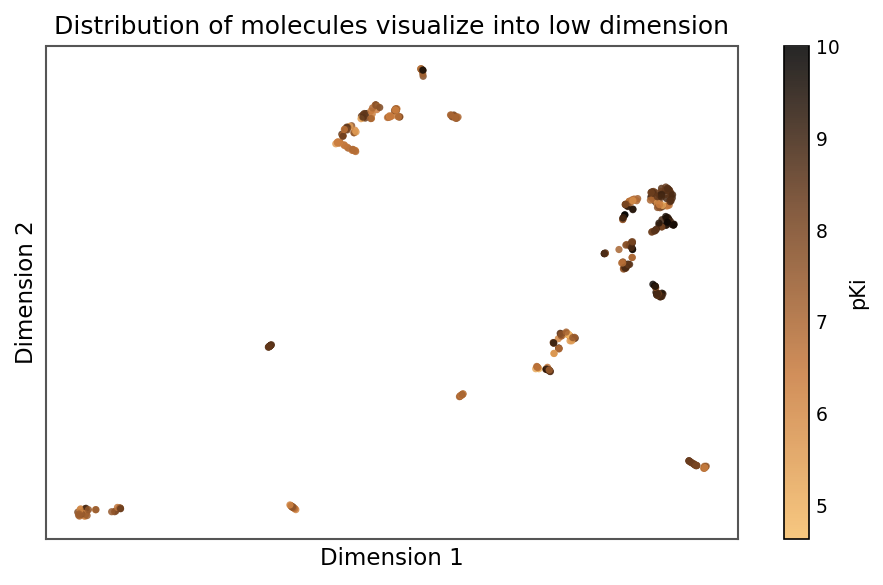

In [156]:
paper_cmap = LinearSegmentedColormap.from_list("paper_orange_black",
                                                            [
                                                                "#F6BE6A",   # light orange
                                                                "#C97B3D",   # brown-orange
                                                                "#70401F",   # dark brown
                                                                "#000000"    # black
                                                            ])

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
scatter = ax.scatter( train_dataset['UMAP_1'], train_dataset['UMAP_2'], c=train_dataset['pIC50'], cmap=paper_cmap, s=12, alpha=0.85, edgecolors='none')

ax.set_xlabel("Dimension 1",fontsize=11)
ax.set_ylabel("Dimension 2", fontsize=11)
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Thin gray border
for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1.0)
    
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.06)
cbar.set_label("pKi", fontsize=10)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_linewidth(0.8)

plt.title("Distribution of molecules visualize into low dimension")
plt.tight_layout()
# plt.savefig("plots/UMAP_Bioactivity_Projection.png", dpi=300, bbox_inches="tight")
plt.show()